## Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/output.csv")

In [5]:
df.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '..."
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q..."
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{}
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{}
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{}


In [6]:
import torch

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


## Make TensorFlow use GPU efficiently (IMPORTANT)

Add this to avoid crashes:

In [7]:
import tensorflow as tf

print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("✅ GPU configured safely")

Num GPUs: 1
✅ GPU configured safely


In [ ]:
# Load model

import ast
import re
import spacy
import pickle

nlp = spacy.load("en_core_web_sm")

# Ensure string
df["Headline"] = df["Headline"].astype(str)
df["Title entity"] = df["Title entity"].astype(str)
df["Entity content"] = df["Entity content"].astype(str)

# -----------------------------
# Helper: Normalize text
# -----------------------------
def normalize(text):
    return re.sub(r"\s+", " ", text.strip())

In [ ]:
# -----------------------------
# Entity Type Inference
# -----------------------------
def infer_entity_type(name, meta=None):
    name_clean = name.strip()
    name_lower = name_clean.lower()

    doc = nlp(name_clean)

    label_map = {
    "PERSON": "PER",
    "GPE": "LOC",
    "LOC": "LOC",
    "ORG": "ORG",
    "DATE": "DATE"
}

    if doc.ents:
        for ent in doc.ents:
            if ent.text.lower() in name_lower:
                return label_map.get(ent.label_, "MISC")

    # DATE
    if re.search(r"\b\d{4}\b", name):
        return "DATE"

    # LOCATION
    if any(x in name_lower for x in ["city", "country", "state", "washington", "india", "usa", "uk"]):
        return "LOC"

    # ORG
    ORG_KEYWORDS = ["inc", "ltd", "corp", "company", "fc", "university", "bank", "group", "agency", "committee"]
    if any(k in name_lower for k in ORG_KEYWORDS):
        return "ORG"

    # PERSON 
    if len(name_clean.split()) >= 2 and name_clean.replace(".", "").istitle():
        return "PER"

    return "MISC"

In [ ]:
# -----------------------------
# Extract Entities from columns
# -----------------------------
def extract_entities(title_ent_str, content_ent_str):
    entities = {}

    # Title entity
    try:
        title_dict = ast.literal_eval(title_ent_str)
        for k, v in title_dict.items():
            entities[k] = v
    except:
        pass

    # Entity content (optional enrichment)
    try:
        content_dict = ast.literal_eval(content_ent_str)
        for k, v in content_dict.items():
            entities[k] = k
    except:
        pass

    return entities

In [ ]:
# -----------------------------
# Convert to BIO
# -----------------------------
def convert_to_bio(text, title_ent_str, content_ent_str):
    text = normalize(text)
    doc = nlp(text)

    tokens = [token.text for token in doc]
    tags = ["O"] * len(tokens)

    entities = extract_entities(title_ent_str, content_ent_str)

    # Create char map: token idx -> char span
    token_spans = [(token.idx, token.idx + len(token.text)) for token in doc]

    entities = dict(sorted(entities.items(), key=lambda x: len(x[0]), reverse=True))

    for surface, expanded in entities.items():

        ent_type = infer_entity_type(expanded)

        # Find all matches (case-insensitive)
        pattern = r'(?<!\w)' + re.escape(surface) + r'(?!\w)'
        for match in re.finditer(pattern, text, re.IGNORECASE):
            start_char, end_char = match.start(), match.end()

            # Map to tokens
            token_indices = []
            for i, (s, e) in enumerate(token_spans):
                if not (e <= start_char or s >= end_char):
                    token_indices.append(i)

            if not token_indices:
                continue

            # Assign BIO tags
            if any(tags[i] != "O" for i in token_indices):
                continue
            tags[token_indices[0]] = f"B-{ent_type}"

            for idx in token_indices[1:]:
                tags[idx] = f"I-{ent_type}"

    return tokens, tags

In [ ]:
# -----------------------------
# Build Dataset
# -----------------------------
sentences = []
labels = []

for _, row in df.iterrows():
    tokens, tags = convert_to_bio(
        row["Headline"],
        row["Title entity"],
        row["Entity content"]
    )
    sentences.append(tokens)
    labels.append(tags)

print("✅ DATA READY:", len(sentences))

# -----------------------------
# Preview
# -----------------------------
for i in range(5):
    print(sentences[i])
    print(labels[i])
    print("Entities:", [t for t in labels[i] if t != "O"])
    print()


✅ DATA READY: 113762
['Predicting', 'Atlanta', 'United', "'s", 'lineup', 'against', 'Columbus', 'Crew', 'in', 'the', 'U.S.', 'Open', 'Cup']
['O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Entities: ['B-LOC', 'I-LOC', 'I-LOC']

['Mitch', 'McConnell', ':', 'DC', 'statehood', 'push', 'is', "'", 'full', 'bore', 'socialism', "'"]
['O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Entities: ['B-LOC']

['Home', 'In', 'North', 'Highlands', 'Damaged', 'By', 'Fire']
['O', 'O', 'O', 'O', 'O', 'O', 'O']
Entities: []

['Meghan', 'McCain', 'blames', "'", 'liberal', 'media', "'", 'and', "'", 'third', '-', 'wave', 'feminism', "'", 'after', 'getting', 'heat', 'over', 'husband', "'s", 'Kamala', 'Harris', 'T', '-', 'shirts']
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Entities: []

['Today', 'in', 'History', ':', 'Aug', '1']
['O', 'O', 'O', 'O', 'O', 'O']
Entities: []



In [11]:
        # ✅ SAVE
with open("/content/drive/MyDrive/NER_DL/processed_data.pkl", "wb") as f:
    pickle.dump({"sentences": sentences, "labels": labels}, f)

print("✅ Data saved!")

✅ Data saved!


In [7]:
import pickle

with open("/content/drive/MyDrive/NER_DL/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

sentences = data["sentences"]
labels = data["labels"]

print("✅ Loaded sentences:", len(sentences))

✅ Loaded sentences: 113762


## Build vocab

In [8]:
sentences = [[w.lower() for w in s] for s in sentences]

In [9]:
tag_set = set(t for seq in labels for t in seq)
print(tag_set)

{'I-DATE', 'O', 'B-DATE', 'I-ORG', 'B-PER', 'B-MISC', 'B-ORG', 'B-LOC', 'I-MISC', 'I-LOC', 'I-PER'}


In [10]:
# Vocabulary limit
from collections import Counter

MAX_VOCAB = 20000
word_counts = Counter(w for s in sentences for w in s)
most_common = word_counts.most_common(MAX_VOCAB)

word2idx = {w: i+2 for i, (w, _) in enumerate(most_common)}
word2idx["<PAD>"] = 0
word2idx["<OOV>"] = 1

# Tag vocab
tag2idx = {"<PAD>": 0}
for i, tag in enumerate(sorted(tag_set)):
    tag2idx[tag] = i + 1

idx2tag = {v: k for k, v in tag2idx.items()}

## Convert to sequences

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Encode X
X = [[word2idx.get(w, word2idx["<OOV>"]) for w in seq] for seq in sentences]
X = pad_sequences(X, maxlen=80, padding="post", value=word2idx["<PAD>"])

# Encode y (NO one-hot)
y = [[tag2idx[t] for t in seq] for seq in labels]
y = pad_sequences(y, maxlen=80, padding="post", value=tag2idx["<PAD>"])

print("X:", X.shape)
print("y:", y.shape)

X: (113762, 80)
y: (113762, 80)


In [12]:
char_set = set(c.lower() for s in sentences for w in s for c in w)

char2idx = {c: i+2 for i, c in enumerate(sorted(char_set))}
char2idx["<PAD>"] = 0
char2idx["<OOV>"] = 1

In [13]:
import numpy as np
MAX_LEN = 80
MAX_CHAR_LEN = 12

def encode_chars(sentences):
    char_data = []

    for sent in sentences:
        sent_chars = []

        for word in sent:
            chars = [char2idx.get(c, 1) for c in word[:MAX_CHAR_LEN]]
            chars = chars + [0] * (MAX_CHAR_LEN - len(chars))
            sent_chars.append(chars)

        # 🔥 FIX: pad to MAX_LEN (80)
        sent_chars = sent_chars + [[0]*MAX_CHAR_LEN] * (MAX_LEN - len(sent))
        char_data.append(sent_chars[:MAX_LEN])

    return np.array(char_data)

X_char = encode_chars(sentences)

In [14]:
# After building X, y

with open("/content/drive/MyDrive/NER_DL/encoded_data.pkl", "wb") as f:
    pickle.dump({
        "X": X,
        "y": y,
        "word2idx": word2idx,
        "tag2idx": tag2idx,
        "idx2tag": idx2tag,
        "char2idx": char2idx,
        "MAX_LEN": MAX_LEN,
    "MAX_CHAR_LEN": MAX_CHAR_LEN
    }, f)

print("✅ Encoded data saved")

✅ Encoded data saved


## Train-test split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, Xc_train, Xc_val = train_test_split(
    X, y, X_char,
    test_size=0.2,
    random_state=42
)

In [31]:
pickle.dump({
    "X_train": X_train,
    "X_val": X_val,
    "y_train": y_train,
    "y_val": y_val,
    "Xc_train": Xc_train,
    "Xc_val": Xc_val
}, open("splits.pkl", "wb"))

In [16]:
print(X_char.shape)
print(X_train.shape)
print(Xc_train.shape)
print(y_train.shape)

i = 0

print("Words:", X_train[i][:10])
print("Chars:", Xc_train[i][:2])  # first 2 words
print("Tags:", y_train[i][:10])

(113762, 80, 12)
(91009, 80)
(91009, 80, 12)
(91009, 80)
Words: [ 342 1157  362   12 1146 5487 2252   23  593 1055]
Chars: [[53 55 46 51 40 42  0  0  0  0  0  0]
 [60 46 49 49 46 38 50  0  0  0  0  0]]
Tags: [11  5 11 11 11 11 11 11 11 11]


## Final stats

In [17]:
EMBED_DIM = 100
VOCAB_SIZE = len(word2idx)
NUM_TAGS = len(tag2idx)

print("VOCAB SIZE:", VOCAB_SIZE)
print("NUM TAGS:", NUM_TAGS)

VOCAB SIZE: 20002
NUM TAGS: 12


In [20]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.3 MB/s eta 0:00:00


In [18]:
import numpy as np
from gensim.models import Word2Vec

# Train Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)
embedding_w2v = np.zeros((VOCAB_SIZE, EMBED_DIM))

# 🔹 STEP 2: build embedding matrix
for word, idx in word2idx.items():

    if word == "<PAD>":
        embedding_w2v[idx] = np.zeros(EMBED_DIM)

    elif word.lower() in w2v_model.wv:
        embedding_w2v[idx] = w2v_model.wv[word.lower()]

    else:
        embedding_w2v[idx] = np.random.normal(0, 0.6, EMBED_DIM)

In [19]:
# GloVe
import numpy as np

GLOVE_PATH = "/content/drive/MyDrive/glove.6B.100d.txt"


glove_index = {}
with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_index[word] = vector

print("Total embeddings found:", len(glove_index))

# Matrix

embedding_glove = np.zeros((VOCAB_SIZE, 100))

for w, i in word2idx.items():

    if w == "<PAD>":
        embedding_glove[i] = np.zeros(100)

    elif w.lower() in glove_index:
        embedding_glove[i] = glove_index[w.lower()]

    else:
        embedding_glove[i] = np.random.normal(scale=0.6, size=(100,))

Total embeddings found: 400000


## BiLSTM MODE

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


def build_bilstm_v2(embedding_matrix):

    inp = Input(shape=(MAX_LEN,))

    x = Embedding(
        VOCAB_SIZE,
        EMBED_DIM,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=True
    )(inp)

    # 🔥 STACKED BiLSTM 
    x = Bidirectional(LSTM(128, return_sequences=True))(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    x = Dropout(0.4)(x)

    out = TimeDistributed(Dense(NUM_TAGS, activation="softmax"))(x)

    model = Model(inp, out)

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    return model

## BiLSTM + CHAR MODEL

In [21]:
from tensorflow.keras.layers import TimeDistributed, Concatenate


def build_bilstm_char_v2(embedding_matrix):

    # WORD INPUT
    word_in = Input(shape=(MAX_LEN,))
    word_emb = Embedding(
        VOCAB_SIZE,
        EMBED_DIM,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=True
    )(word_in)

    # CHAR INPUT
    char_in = Input(shape=(MAX_LEN, MAX_CHAR_LEN))

    char_emb = TimeDistributed(
        Embedding(len(char2idx) + 1, 64, mask_zero=False)
    )(char_in)

    # 🔥 CNN instead of LSTM (FAST)
    from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

    char_enc = TimeDistributed(
        Conv1D(32, kernel_size=3, activation="relu")
    )(char_emb)

    char_enc = TimeDistributed(
        GlobalMaxPooling1D()
    )(char_enc)

    # COMBINE
    x = Concatenate()([word_emb, char_enc])

    # BiLSTM
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    x = Dropout(0.4)(x)

    out = TimeDistributed(Dense(NUM_TAGS, activation="softmax"))(x)

    model = Model([word_in, char_in], out)

    model.compile(
        optimizer=Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Padding Mask (for ignoring PAD tokens)

In [22]:
import numpy as np

sample_weights_train = (y_train != tag2idx["<PAD>"]).astype(float)
sample_weights_val = (y_val != tag2idx["<PAD>"]).astype(float)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [24]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

In [25]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [32]:
results = []
models_dict = {}

print("\nTraining MODEL-1: BiLSTM + Word2Vec")

model_1 = build_bilstm_v2(embedding_w2v)

model_1.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    validation_data=(X_val, y_val, sample_weights_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)


Training MODEL-1: BiLSTM + Word2Vec
Epoch 1/5
1422/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9112 - loss: 0.3938
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 51s 31ms/step - accuracy: 0.9251 - loss: 0.2862 - val_accuracy: 0.9409 - val_loss: 0.1957 - learning_rate: 0.0010
Epoch 2/5
1422/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9441 - loss: 0.1796
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - accuracy: 0.9449 - loss: 0.1752 - val_accuracy: 0.9455 - val_loss: 0.1762 - learning_rate: 5.0000e-04


In [ ]:
print("\nTraining MODEL-2: BiLSTM + GloVe")

model_2 = build_bilstm_v2(embedding_glove)

model_2.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    validation_data=(X_val, y_val, sample_weights_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)


Training MODEL-2: BiLSTM + GloVe
Epoch 1/5
1422/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9126 - loss: 0.3788
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9265 - loss: 0.2742 - val_accuracy: 0.9408 - val_loss: 0.1912 - learning_rate: 0.0010
Epoch 2/5
1421/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9441 - loss: 0.1790
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9448 - loss: 0.1751 - val_accuracy: 0.9454 - val_loss: 0.1733 - learning_rate: 5.0000e-04


In [34]:
model_3 = build_bilstm_char_v2(embedding_w2v)

model_3.fit(
    [X_train, Xc_train], y_train, sample_weight=sample_weights_train,
    validation_data=([X_val, Xc_val], y_val, sample_weights_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/5
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1352 - loss: 0.0560
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 175s 107ms/step - accuracy: 0.1364 - loss: 0.0414 - val_accuracy: 0.1386 - val_loss: 0.0283 - learning_rate: 0.0010
Epoch 2/5
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1391 - loss: 0.0263
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 137s 96ms/step - accuracy: 0.1392 - loss: 0.0259 - val_accuracy: 0.1391 - val_loss: 0.0256 - learning_rate: 5.0000e-04


In [26]:
print("\nTraining MODEL - 4: BiLSTM + GloVe + Char")

model_4 = build_bilstm_char_v2(embedding_glove)
model_4.fit(
    [X_train, Xc_train], y_train,
    sample_weight=sample_weights_train,
    validation_data=([X_val, Xc_val], y_val, sample_weights_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)


Training MODEL - 4: BiLSTM + GloVe + Char
Epoch 1/5
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 186s 109ms/step - accuracy: 0.1368 - loss: 0.0395 - val_accuracy: 0.1385 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 2/5
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 138s 97ms/step - accuracy: 0.1392 - loss: 0.0257 - val_accuracy: 0.1393 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 3/5
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 138s 97ms/step - accuracy: 0.1403 - loss: 0.0216 - val_accuracy: 0.1396 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 4/5
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1410 - loss: 0.0186
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 137s 96ms/step - accuracy: 0.1410 - loss: 0.0188 - val_accuracy: 0.1397 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 5/5
1423/1423 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1421 - loss: 0.0154
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1423/1423 ━━━━

In [28]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=3b137548853813270223af418a6426c44f445d959785e4448209d721250d7e32
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
from seqeval.metrics import f1_score, precision_score, recall_score

def evaluate_entity_level(model, X_val, y_val, idx2tag, model_name, embed_name):

    MAX_EVAL = 3000   

    # Slice data (important for speed)
    if isinstance(X_val, list):
        X_eval = [x[:MAX_EVAL] for x in X_val]
    else:
        X_eval = X_val[:MAX_EVAL]

    y_eval = y_val[:MAX_EVAL]

    preds = model.predict(X_eval, batch_size=128).argmax(axis=-1)

    true_seq = []
    pred_seq = []

    for t_seq, p_seq in zip(y_eval, preds):

        t_labels = []
        p_labels = []

        for t, p in zip(t_seq, p_seq):

            if idx2tag[t] == "<PAD>":
                continue

            t_labels.append(idx2tag[t])
            p_labels.append(idx2tag[p])

        true_seq.append(t_labels)
        pred_seq.append(p_labels)


    precision = precision_score(true_seq, pred_seq)
    recall = recall_score(true_seq, pred_seq)
    f1 = f1_score(true_seq, pred_seq)

    print(f"\n📊 {model_name} ({embed_name})")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    return {
        "Model": model_name,
        "Embedding": embed_name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

## ✅ 3. Run evaluation (FINAL)

In [35]:
results = []

results.append(evaluate_entity_level(model_1, X_val, y_val, idx2tag, "BiLSTM", "Word2Vec"))
results.append(evaluate_entity_level(model_2, X_val, y_val, idx2tag, "BiLSTM", "GloVe"))
results.append(evaluate_entity_level(model_3, [X_val, Xc_val], y_val, idx2tag, "BiLSTM-Char", "Word2Vec"))
results.append(evaluate_entity_level(model_4, [X_val, Xc_val], y_val, idx2tag, "BiLSTM-Char", "GloVe"))

import pandas as pd

df_result = pd.DataFrame(results)
print("\n📊 FINAL COMPARISON:\n")
print(df_result)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step

📊 BiLSTM (Word2Vec)
Precision: 0.6347, Recall: 0.5195, F1: 0.5714
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step

📊 BiLSTM (GloVe)
Precision: 0.6790, Recall: 0.4743, F1: 0.5584
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step

📊 BiLSTM-Char (Word2Vec)
Precision: 0.6676, Recall: 0.5087, F1: 0.5774
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step

📊 BiLSTM-Char (GloVe)
Precision: 0.6896, Recall: 0.6005, F1: 0.6420

📊 FINAL COMPARISON:

         Model Embedding  Precision    Recall  F1 Score
0       BiLSTM  Word2Vec   0.634703  0.519518  0.571363
1       BiLSTM     GloVe   0.678954  0.474252  0.558435
2  BiLSTM-Char  Word2Vec   0.667575  0.508721  0.577422
3  BiLSTM-Char     GloVe   0.689557  0.600498  0.641953


In [53]:
df_result.to_csv("dl_results.csv", index=False)

In [36]:
# Save ALL models
model_1.save("model_1.keras")
model_2.save("model_2.keras")
model_3.save("model_3.keras")
model_4.save("model_4.keras")

## ✅ 4. Select best model

In [37]:
best_row = df_result.loc[df_result["F1 Score"].idxmax()]
print("\n🏆 BEST MODEL:\n", best_row)


🏆 BEST MODEL:
 Model        BiLSTM-Char
Embedding          GloVe
Precision       0.689557
Recall          0.600498
F1 Score        0.641953
Name: 3, dtype: object


## ✅ 5. Save best model (correct mapping)

In [38]:
best_tuple = (best_row["Model"], best_row["Embedding"])

model_map = {
    ("BiLSTM", "Word2Vec"): model_1,
    ("BiLSTM", "GloVe"): model_2,
    ("BiLSTM-Char", "Word2Vec"): model_3,
    ("BiLSTM-Char", "GloVe"): model_4,
}

best_model = model_map[best_tuple]

best_model.save("final_best_model.keras")

In [43]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
import spacy

nlp = spacy.load("en_core_web_sm")

def predict_ner(text):
    doc = nlp(text)
    tokens = [token.text for token in doc]

    # WORD encoding
    encoded = [word2idx.get(w.lower(), word2idx["<OOV>"]) for w in tokens]

    padded = pad_sequences(
        [encoded],
        maxlen=MAX_LEN,
        padding="post",
        value=word2idx["<PAD>"]
    )

    # 🔥 CHAR encoding
    char_seq = []
    for word in tokens:
        chars = [char2idx.get(c.lower(), 1) for c in word[:MAX_CHAR_LEN]]
        chars += [0] * (MAX_CHAR_LEN - len(chars))
        char_seq.append(chars)

    char_seq += [[0]*MAX_CHAR_LEN] * (MAX_LEN - len(tokens))
    char_seq = np.array([char_seq[:MAX_LEN]])

    # 🔥 Handle model type
    if len(best_model.inputs) == 2:
        pred = best_model.predict([padded, char_seq])[0].argmax(axis=-1)
    else:
        pred = best_model.predict(padded)[0].argmax(axis=-1)

    tags = [idx2tag[idx] for idx in pred][:len(tokens)]

    return list(zip(tokens, tags))

In [39]:
def extract_entities(tokens_with_tags):
    entities = {}
    current_entity = []
    current_tag = None

    for token, tag in tokens_with_tags:

        if tag.startswith("B-"):
            if current_entity:
                entities.setdefault(current_tag, []).append(" ".join(current_entity))

            current_entity = [token]
            current_tag = tag[2:]

        elif tag.startswith("I-") and current_tag == tag[2:]:
            current_entity.append(token)

        else:
            if current_entity:
                entities.setdefault(current_tag, []).append(" ".join(current_entity))

            current_entity = []
            current_tag = None

    if current_entity:
        entities.setdefault(current_tag, []).append(" ".join(current_entity))

    return entities

In [44]:
text = "Barack Obama visited New York in 2015"
print("INPUT TEXT:", text)

token_tags = predict_ner(text)

print("\nToken Prediction:")
for tok, tag in token_tags:
    print(f"{tok:12} --> {tag}")

final_entities = extract_entities(token_tags)

print("\nExtracted Entities:")
for ent_type, values in final_entities.items():
    print(f"{ent_type}: {', '.join(values)}")

INPUT TEXT: Barack Obama visited New York in 2015
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Token Prediction:
Barack       --> B-PER
Obama        --> I-PER
visited      --> O
New          --> B-LOC
York         --> I-LOC
in           --> O
2015         --> O

Extracted Entities:
PER: Barack Obama
LOC: New York


## NER-Focused EDA

In [45]:
# ✅ 1.1 Count entity distribution

from collections import Counter
import matplotlib.pyplot as plt

entity_counts = Counter()

for seq in labels:
    for tag in seq:
        if tag != "O" and tag != "<PAD>":
            entity_counts[tag.split("-")[1]] += 1

print(entity_counts)

Counter({'PER': 34178, 'MISC': 31265, 'LOC': 30181, 'ORG': 27446, 'DATE': 3393})


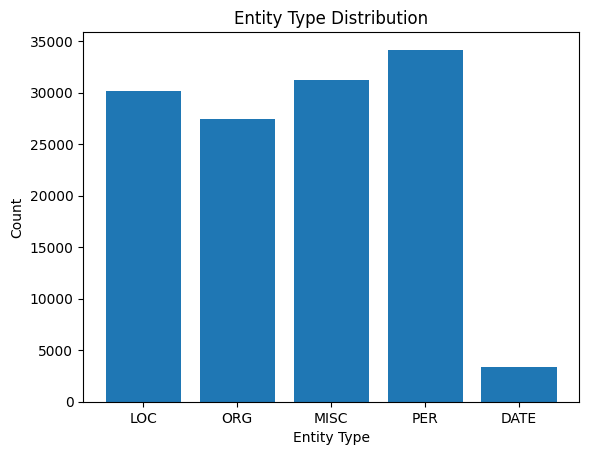

In [46]:
# 📊 1.2 Visualization (Bar chart)

plt.figure()
plt.bar(entity_counts.keys(), entity_counts.values())
plt.title("Entity Type Distribution")
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.show()

In [47]:
# ✅ 1.3 Show entity-rich sentences

def show_entity_rich_samples(sentences, labels, top_n=5):
    scored = []

    for sent, tag_seq in zip(sentences, labels):
        count = sum(1 for t in tag_seq if t != "O")
        scored.append((count, sent, tag_seq))

    scored.sort(reverse=True, key=lambda x: x[0])

    for i in range(top_n):
        print(f"\nSentence {i+1}:")
        print(" ".join(scored[i][1]))
        print("Tags:", scored[i][2])

show_entity_rich_samples(sentences, labels)


Sentence 1:
inside kim kardashian and kanye west 's palatial $ 60 million mansion where the sinks are magic , tvs come out of the floor , and everything is beige
Tags: ['O', 'B-PER', 'I-PER', 'O', 'B-PER', 'I-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER']

Sentence 2:
colorado couple is now suing the dominican resort where three americans have died , saying they woke up in a room ' reeking of chemicals , covered in sweat , dizzy and with stomach cramps '
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'I-MISC']

Sentence 3:
pittsburgh steelers wide receiver juju smith - schuster reacts to oakland raiders wide receiver antonio brown ,

## 2. Overall Text Statistics


In [48]:
# 2.1 Vocabulary Size

vocab = set(w for s in sentences for w in s)
print("Vocabulary Size:", len(vocab))

Vocabulary Size: 46078


In [49]:
# 2.2 Most frequent unigrams

from collections import Counter

word_counts = Counter(w for s in sentences for w in s)

print("\nTop 10 Unigrams:")
print(word_counts.most_common(10))


Top 10 Unigrams:
[('to', 29176), ("'", 28241), ('the', 27134), ('in', 26123), (',', 25877), (':', 23868), ('-', 20342), ("'s", 20042), ('of', 16906), ('for', 15068)]


In [50]:
# 2.3 Most frequent bigrams

from collections import Counter

bigrams = []

for s in sentences:
    for i in range(len(s)-1):
        bigrams.append((s[i], s[i+1]))

bigram_counts = Counter(bigrams)

print("\nTop 10 Bigrams:")
print(bigram_counts.most_common(10))


Top 10 Bigrams:
[(('of', 'the'), 2139), (('in', 'the'), 2105), ((':', "'"), 1623), (('-', 'year'), 1554), (('here', "'s"), 1339), ((':', 'what'), 1297), (('on', 'the'), 1150), (('-', 'old'), 1149), (('year', '-'), 1093), (('how', 'to'), 1044)]


## TF-IDF Heatmap

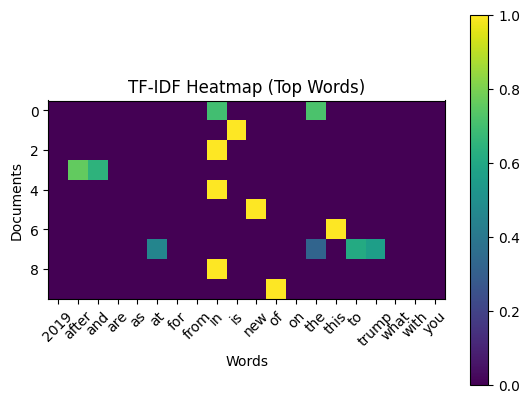

In [51]:
# Prepare sentences as text
texts = [" ".join(s) for s in sentences]

# Compute TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20)
X_tfidf = vectorizer.fit_transform(texts)

feature_names = vectorizer.get_feature_names_out()

# Plot Heatmap

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(X_tfidf[:10].toarray())
plt.title("TF-IDF Heatmap (Top Words)")
plt.xlabel("Words")
plt.ylabel("Documents")
plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.colorbar()
plt.show()

In [52]:
# Entity-wise word distribution

entity_words = {}

for sent, tag_seq in zip(sentences, labels):
    for word, tag in zip(sent, tag_seq):
        if tag.startswith("B-") or tag.startswith("I-"):
            ent = tag.split("-")[1]
            entity_words.setdefault(ent, []).append(word)

for ent, words in entity_words.items():
    print(f"\nTop words in {ent}:")
    print(Counter(words).most_common(5))


Top words in LOC:
[("'s", 1061), ('u.s.', 711), ('us', 635), ('new', 527), ('california', 510)]

Top words in ORG:
[('nba', 682), ('nfl', 630), ("'s", 627), ('world', 442), ('cup', 398)]

Top words in MISC:
[('-', 457), ("'s", 390), ('cup', 296), ('police', 266), ('football', 212)]

Top words in PER:
[('trump', 1995), ("'s", 1172), ('kevin', 349), ('lakers', 335), ('durant', 328)]

Top words in DATE:
[('2019', 658), ('2020', 225), ('july', 198), ('cup', 192), ('world', 191)]
